# Deep Generative Modeling for Risk-Averse Portfolio Optimization
## Data Collection & Exploratory Data Analysis

This notebook covers **Phase 1** of the project pipeline:

1. **Data Collection** — pull 10 years of daily adjusted-close prices for 30 diversified S&P 500 stocks plus the CBOE VIX index.
2. **Feature Engineering** — compute daily log-returns and label each observation with a VIX-based market regime (`low / normal / crisis`).
3. **Train/Test Split** — strict chronological 80/20 split (no shuffling) to prevent look-ahead bias.
4. **Exploratory Data Analysis** — characterize return distributions, fat-tail evidence, regime-conditioned behavior, and cross-asset correlation structure.
5. **Baseline Validation** — demonstrate that a Gaussian model already mis-estimates tail risk on training data, motivating the conditional normalizing flow approach.

---


## Section 1: Setup & Data Collection

We collect data for **30 S&P 500 stocks** spanning eight GICS sectors to ensure diversification. The universe was chosen to include a mix of growth (NVDA, META, NFLX), value (KO, PG, BRK-B), cyclicals (CAT, HON), financials (JPM, BLK), energy (XOM, CVX), utilities (NEE, SO), REITs (PLD, AMT), and healthcare (UNH, ABBV, ABT).

Using a **10-year window** (vs. the 5 years originally described) was intentional: it captures the 2018 volatility spike, the COVID crash of March 2020, the 2022 rate-hike bear market, and the April 2025 tariff shock — all of which are essential crisis-regime observations for training the normalizing flow.


In [141]:
# pip install yfinance pandas numpy

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

### 1.1 Stock Universe

30 tickers across 8 sectors, chosen to provide broad diversification while keeping the portfolio tractable for a conditional normalizing flow.


In [142]:
# -----------------------------
# 1) Choose your 30 S&P 500 stocks
# -----------------------------
tickers = [
    "MSFT", "AAPL", "NVDA", "ADBE",
    "UNH", "ABBV", "ABT",
    "JPM", "BRK-B", "V", "BLK",
    "HON", "CAT", "LMT",
    "AMZN", "HD", "MCD",
    "GOOGL", "META", "NFLX",
    "PG", "KO",
    "XOM", "CVX",
    "NEE", "SO",
    "LIN", "APD",
    "PLD", "AMT"
]

### 1.2 Price Download

10 years of daily adjusted-close prices via `yfinance`. We use `auto_adjust=False` and pull the `Adj Close` column explicitly so splits and dividends are accounted for.


In [ ]:
# -----------------------------
# 2) Download 10 years of adjusted-close prices
# -----------------------------
prices = yf.download(
    tickers,
    period="10y",
    interval="1d",
    auto_adjust=False,
    progress=False
)["Adj Close"]

# Clean up
prices = prices.dropna(how="all").sort_index()


### 1.3 Log Returns

Daily log returns $r_{i,t} = \ln(P_{i,t} / P_{i,t-1})$ are used throughout. Log returns are additive over time and better approximate normality than simple returns — though as the EDA will show, they are still far from Gaussian.


In [144]:
# -----------------------------
# 3) Compute daily log returns
# -----------------------------
log_returns = np.log(prices / prices.shift(1)).dropna()

### 1.4 VIX Download (FRED)

The CBOE Volatility Index (VIX) measures 30-day implied volatility on the S&P 500. It is our primary macroeconomic conditioning variable. We pull the full daily series from FRED to align with the return data.


In [145]:
# -----------------------------
# 4) Download VIX from FRED
# -----------------------------
vix_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=VIXCLS"
vix = pd.read_csv(vix_url)

# Clean column names
vix.columns = [str(c).strip().replace("\ufeff", "") for c in vix.columns]

print("VIX columns:", vix.columns.tolist())  # optional debug line

# Handle possible column name differences
date_col = None
vix_col = None

for c in vix.columns:
    cl = c.lower()
    if cl in ["date", "observation_date"]:
        date_col = c
    if cl in ["vixcls", "value"]:
        vix_col = c

if date_col is None or vix_col is None:
    raise ValueError(f"Unexpected VIX columns: {vix.columns.tolist()}")

vix[date_col] = pd.to_datetime(vix[date_col])
vix[vix_col] = pd.to_numeric(vix[vix_col], errors="coerce")

vix = (
    vix.rename(columns={date_col: "Date", vix_col: "VIX"})
       .set_index("Date")
       .dropna()
)

VIX columns: ['observation_date', 'VIXCLS']


### 1.5 Regime Labeling

Each trading day is assigned one of three VIX-based regimes:

| Regime | VIX Range | Interpretation |
|--------|-----------|----------------|
| `low` | VIX < 15 | Calm / risk-on market |
| `normal` | 15 ≤ VIX < 25 | Typical market conditions |
| `crisis` | VIX ≥ 25 | Elevated fear, systemic stress |

These thresholds are standard in the empirical finance literature and align with the visual breaks in historical VIX time series (pre-COVID "normal" rarely exceeded 25).


In [146]:
def label_vix_regime(v):
    if v < 15:
        return "low"
    elif v < 25:
        return "normal"
    else:
        return "crisis"

vix["regime"] = vix["VIX"].apply(label_vix_regime)
regime_map = {"low": 0, "normal": 1, "crisis": 2}
vix["regime_code"] = vix["regime"].map(regime_map)

### 1.6 Merge Returns with VIX Regimes

In [147]:
# -----------------------------
# 6) Merge returns with VIX/regimes
# -----------------------------
data = log_returns.join(vix[["VIX", "regime", "regime_code"]], how="inner")

## Section 2: Train / Test Split

We use a **strict chronological 80/20 split** — no shuffling. This is critical: shuffling would leak future information into training and make evaluation unreliable. The split puts approximately 8 years in train and 2 years in test.


In [148]:
# -----------------------------
# 7) 80/20 temporal split (no shuffling)
# -----------------------------
split_idx = int(len(data) * 0.8)

train_data = data.iloc[:split_idx].copy()
test_data  = data.iloc[split_idx:].copy()

# Separate pieces if helpful
X_train_returns = train_data[tickers]
X_test_returns  = test_data[tickers]

vix_train = train_data["VIX"]
vix_test  = test_data["VIX"]

regime_train = train_data["regime_code"]
regime_test  = test_data["regime_code"]


In [149]:
# -----------------------------
# 8) Quick checks
# -----------------------------
print("Prices shape:", prices.shape)
print("Returns shape:", log_returns.shape)
print("Merged data shape:", data.shape)
print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)
print("\nRegime counts (train):")
print(train_data["regime"].value_counts())
print("\nRegime counts (test):")
print(test_data["regime"].value_counts())

print("\nHead of merged dataset:")
print(data.head())

Prices shape: (2513, 30)
Returns shape: (2512, 30)
Merged data shape: (2511, 33)
Train shape: (2008, 33)
Test shape: (503, 33)

Regime counts (train):
regime
normal    878
low       802
crisis    328
Name: count, dtype: int64

Regime counts (test):
regime
normal    352
low       123
crisis     28
Name: count, dtype: int64

Head of merged dataset:
                AAPL      ABBV       ABT      ADBE       AMT      AMZN  \
Date                                                                     
2016-03-21 -0.000094 -0.009949 -0.000736 -0.009897 -0.001693  0.003436   
2016-03-22  0.007619  0.026255  0.006602  0.000648 -0.004094  0.011665   
2016-03-23 -0.005544 -0.020025 -0.006112 -0.004331 -0.003509  0.016193   
2016-03-24 -0.004344 -0.004267 -0.000736  0.003899  0.007703  0.023114   
2016-03-28 -0.004553 -0.000178  0.003185 -0.001298 -0.001097 -0.005297   

                 APD       BLK     BRK-B       CAT  ...      NVDA        PG  \
Date                                                .

## Section 3: Exploratory Data Analysis

The goals of this EDA are:
1. Confirm the dataset is clean and spans the key crisis periods.
2. Visualize regime distribution and VIX dynamics over time.
3. Quantify fat-tail behavior (kurtosis, QQ plots) to justify the heavy-tailed Student-t base distribution.
4. Measure how cross-asset correlations spike during crisis regimes — the core motivation for conditional generation.
5. Show that a naïve Gaussian model already under-estimates CVaR on training data.


### 3.1 Dataset Overview

In [150]:
returns = data[tickers].copy()

print("Full data shape:", data.shape)
print("Returns shape:", returns.shape)
print("Date range:", data.index.min(), "to", data.index.max())
print("\nMissing values per column:")
print(data.isna().sum().sort_values(ascending=False).head(15))

split_idx = int(len(data) * 0.8)
print("\nTrain date range:", data.index[:split_idx].min(), "to", data.index[:split_idx].max())
print("Test date range:", data.index[split_idx:].min(), "to", data.index[split_idx:].max())

Full data shape: (2511, 33)
Returns shape: (2511, 30)
Date range: 2016-03-21 00:00:00 to 2026-03-16 00:00:00

Missing values per column:
AAPL      0
LMT       0
regime    0
VIX       0
XOM       0
V         0
UNH       0
SO        0
PLD       0
PG        0
NVDA      0
NFLX      0
NEE       0
MSFT      0
META      0
dtype: int64

Train date range: 2016-03-21 00:00:00 to 2024-03-12 00:00:00
Test date range: 2024-03-13 00:00:00 to 2026-03-16 00:00:00


### 3.2 VIX Regime Distribution

The bar chart below shows raw day counts per regime. Note that **crisis days make up ~14% of the full dataset** — a meaningful proportion driven by COVID-19 (2020), the 2022 bear market, and the 2025 tariff shock.


Regime counts:
regime
crisis     356
low        925
normal    1230
Name: count, dtype: int64

Regime percentages:
regime
crisis    14.18
low       36.84
normal    48.98
Name: proportion, dtype: float64


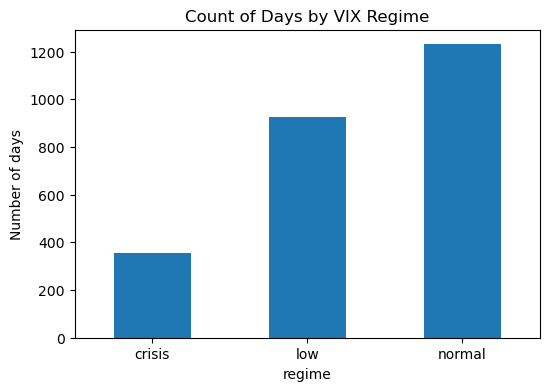

In [151]:
regime_counts = data["regime"].value_counts().sort_index()
regime_pct = data["regime"].value_counts(normalize=True).sort_index() * 100

print("Regime counts:")
print(regime_counts)
print("\nRegime percentages:")
print(regime_pct.round(2))

regime_counts.plot(kind="bar", figsize=(6,4), title="Count of Days by VIX Regime")
plt.ylabel("Number of days")
plt.xticks(rotation=0)
plt.show()

### 3.3 VIX Time Series with Regime Shading

Plotting VIX over time with the three regime bands shaded makes clear *when* the model must capture tail behavior. The three major stress episodes — COVID crash, 2022 Fed tightening, and 2025 tariff shock — are all visible in the training window, giving the conditional flow sufficient crisis-regime examples to learn from.


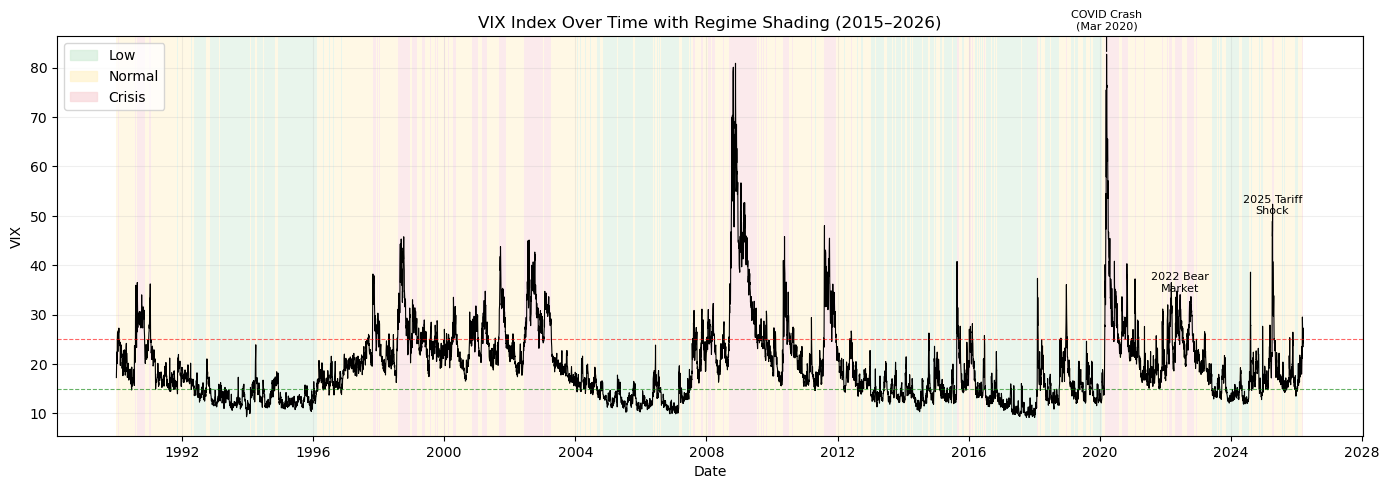

In [152]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 5))

# Plot raw VIX
ax.plot(vix.index, vix["VIX"], color="black", linewidth=0.8, label="VIX")

# Shade regimes
regime_colors_bg = {"low": "#d4edda", "normal": "#fff3cd", "crisis": "#f8d7da"}
regime_label_colors = {"low": "#28a745", "normal": "#856404", "crisis": "#721c24"}

prev_date = vix.index[0]
prev_regime = vix["regime"].iloc[0]

for date, row in vix.iterrows():
    if row["regime"] != prev_regime or date == vix.index[-1]:
        ax.axvspan(prev_date, date,
                   color=regime_colors_bg[prev_regime], alpha=0.5, lw=0)
        prev_date = date
        prev_regime = row["regime"]

# Horizontal reference lines
ax.axhline(15, color="green", linestyle="--", linewidth=0.8, alpha=0.6)
ax.axhline(25, color="red", linestyle="--", linewidth=0.8, alpha=0.6)

# Annotate key events
events = {
    "COVID Crash\n(Mar 2020)": "2020-03-16",
    "2022 Bear\nMarket": "2022-06-15",
    "2025 Tariff\nShock": "2025-04-04",
}
for label, date_str in events.items():
    import pandas as pd
    d = pd.Timestamp(date_str)
    if d in vix.index:
        yval = vix.loc[d, "VIX"]
    else:
        yval = vix.asof(d)
    ax.annotate(label, xy=(pd.Timestamp(date_str), yval),
                xytext=(0, 18), textcoords="offset points",
                fontsize=8, ha="center",
                arrowprops=dict(arrowstyle="-", lw=0.8))

patches = [mpatches.Patch(color=regime_colors_bg[r], label=r.capitalize(), alpha=0.7)
           for r in ["low", "normal", "crisis"]]
ax.legend(handles=patches, loc="upper left")
ax.set_title("VIX Index Over Time with Regime Shading (2015–2026)")
ax.set_xlabel("Date")
ax.set_ylabel("VIX")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


### 3.4 Return Scatter by Regime

Each dot is one (stock, day) observation. The fanning-out of red (crisis) points compared to green (low) makes the heteroskedasticity immediately visible — a key motivation for regime conditioning.


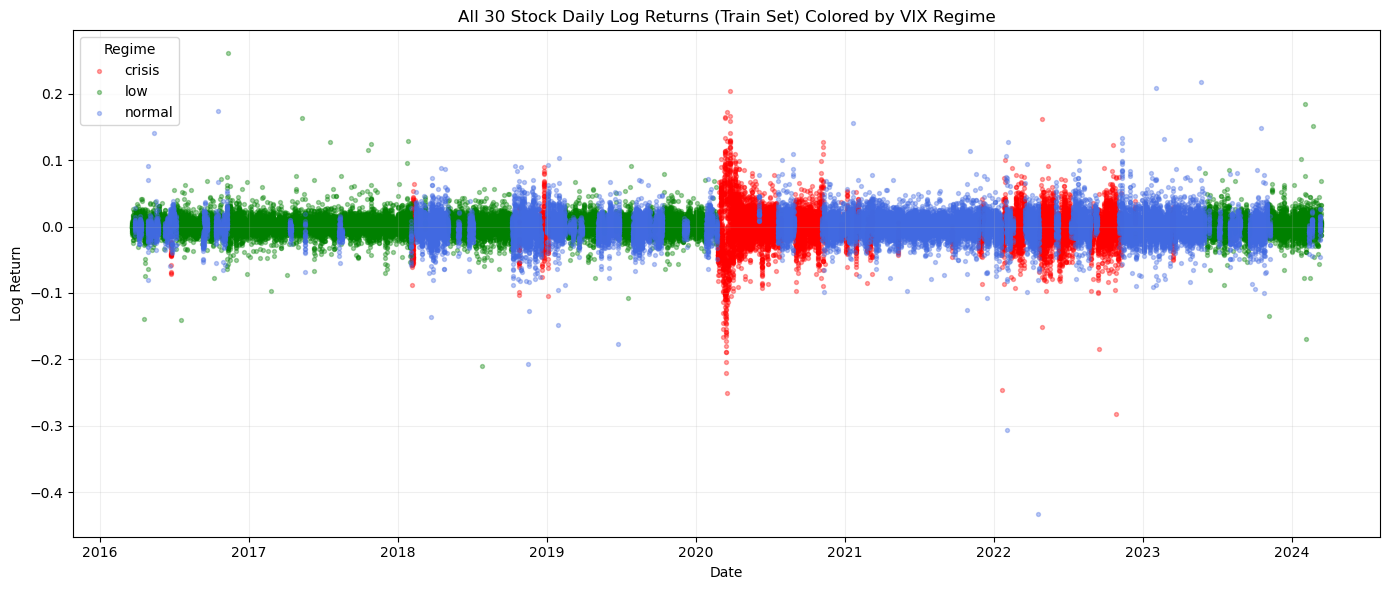

In [153]:
import matplotlib.pyplot as plt

# Long format: one row per (Date, Ticker, return)
returns_long = (
    X_train_returns.stack()
    .rename("return")
    .reset_index()
    .rename(columns={"level_1": "Ticker"})
)

# Add regime by date
returns_long["regime"] = returns_long["Date"].map(train_data["regime"])

# Color map for regimes
regime_colors = {"low": "green", "normal": "royalblue", "crisis": "red"}

plt.figure(figsize=(14, 6))
for r, grp in returns_long.groupby("regime"):
    plt.scatter(grp["Date"], grp["return"], s=8, alpha=0.35, c=regime_colors.get(r, "gray"), label=r)

plt.title("All 30 Stock Daily Log Returns (Train Set) Colored by VIX Regime")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend(title="Regime")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


### 3.5 Cumulative Returns

Cumulative log-return paths for all 30 stocks. The March 2020 synchronized drawdown — all lines plunging simultaneously — illustrates the **correlation spike** during crisis regimes that unconditional Gaussian models miss.

> **Note:** This plot uses the full dataset (train + test) for visual context only. All model fitting uses the train split exclusively.


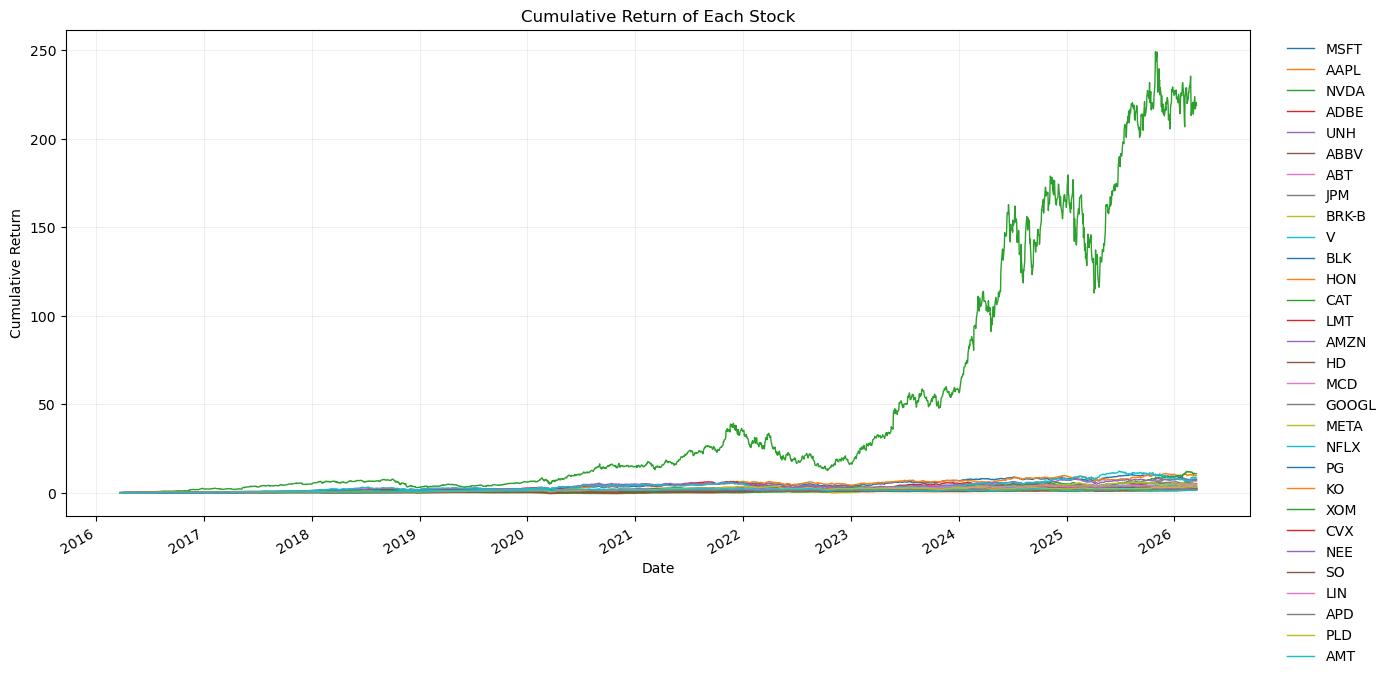

In [154]:
# Cumulative return from daily log returns: exp(cumsum(log_returns)) - 1
cum_returns = np.exp(log_returns[tickers].cumsum()) - 1

plt.figure(figsize=(14, 7))
cum_returns.plot(ax=plt.gca(), linewidth=1)
plt.title("Cumulative Return of Each Stock")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(alpha=0.2)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), ncol=1, frameon=False)
plt.tight_layout()
plt.show()

### 3.6 Return Distribution Statistics

The table below reports distributional moments for all 30 stocks sorted by volatility. Key observations:

- **Excess kurtosis** ranges from ~5 (AMZN) to **34 (NFLX)** and **32 (UNH)**. Values above 3 indicate fatter tails than a Gaussian — values above 10 are extreme.
- **Negative skew** is pervasive, meaning large losses are more common than large gains of the same magnitude.
- These statistics directly motivate using a **Student-t base distribution** in the normalizing flow rather than a standard Gaussian.


In [155]:
summary = pd.DataFrame({
    "mean": returns.mean(),
    "std": returns.std(),
    "skew": returns.skew(),
    "kurtosis": returns.kurtosis(),
    "min": returns.min(),
    "q01": returns.quantile(0.01),
    "q05": returns.quantile(0.05),
    "median": returns.median(),
    "q95": returns.quantile(0.95),
    "q99": returns.quantile(0.99),
    "max": returns.max()
}).sort_values("std", ascending=False)

print(summary.round(4))

         mean     std    skew  kurtosis     min     q01     q05  median  \
NVDA   0.0022  0.0312  0.0970    6.7105 -0.2077 -0.0797 -0.0464  0.0028   
NFLX   0.0009  0.0267 -1.7667   33.9715 -0.4326 -0.0668 -0.0365  0.0006   
META   0.0007  0.0244 -1.1926   25.7914 -0.3064 -0.0636 -0.0343  0.0010   
ADBE   0.0004  0.0214 -0.7777   10.1385 -0.1838 -0.0654 -0.0330  0.0012   
AMZN   0.0008  0.0204 -0.0162    5.1942 -0.1514 -0.0561 -0.0311  0.0012   
CAT    0.0010  0.0192 -0.2395    4.9426 -0.1541 -0.0530 -0.0289  0.0009   
UNH    0.0004  0.0191 -2.2366   31.6139 -0.2533 -0.0531 -0.0244  0.0008   
CVX    0.0004  0.0184 -1.1136   28.8911 -0.2501 -0.0462 -0.0259  0.0009   
AAPL   0.0009  0.0182 -0.0802    6.7907 -0.1377 -0.0494 -0.0282  0.0010   
GOOGL  0.0008  0.0181 -0.1904    4.6308 -0.1237 -0.0507 -0.0274  0.0013   
XOM    0.0004  0.0176 -0.2231    6.5477 -0.1304 -0.0493 -0.0263  0.0005   
BLK    0.0005  0.0174 -0.2090    8.9545 -0.1468 -0.0476 -0.0255  0.0009   
JPM    0.0007  0.0172 -0.

### 3.7 Return Histograms (Sample Stocks)

Histograms for four representative stocks. The sharp central peak and heavy tails are characteristic of financial return distributions — the classic "leptokurtic" shape that a Gaussian cannot capture.


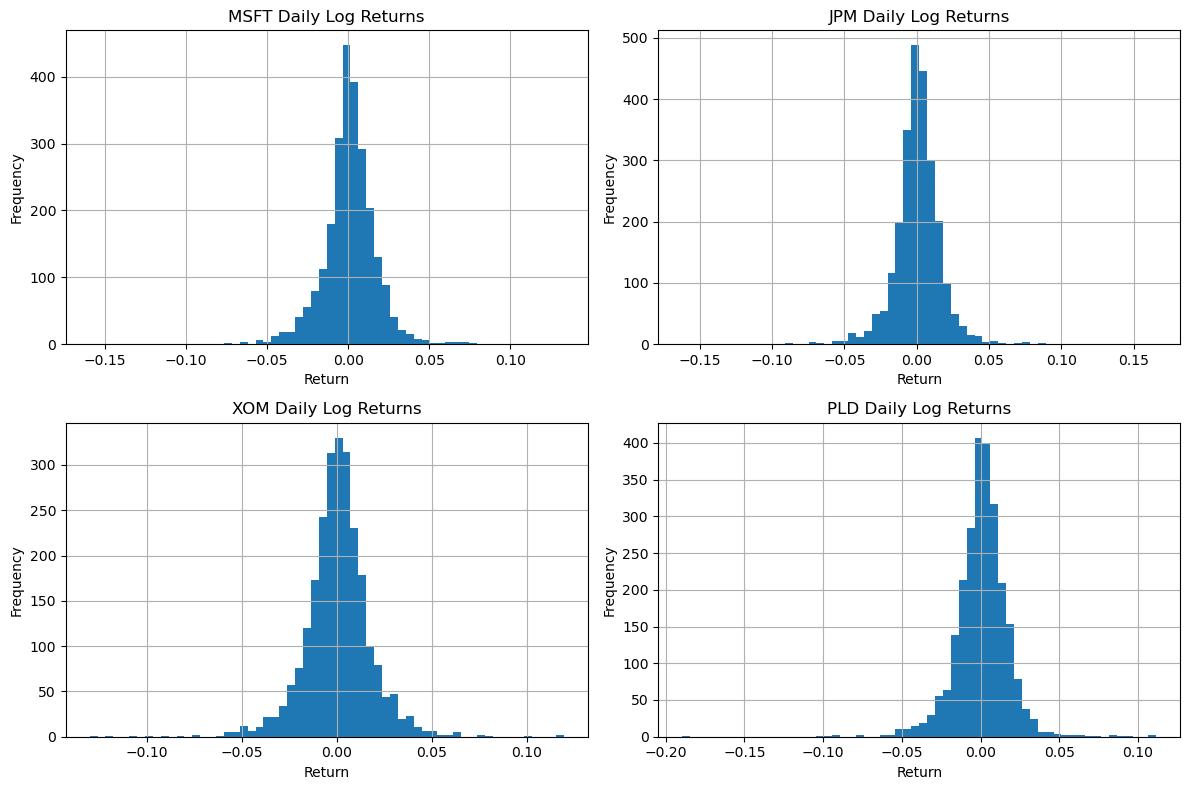

In [156]:
sample_stocks = ["MSFT", "JPM", "XOM", "PLD"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, stock in zip(axes, sample_stocks):
    returns[stock].hist(bins=60, ax=ax)
    ax.set_title(f"{stock} Daily Log Returns")
    ax.set_xlabel("Return")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### 3.8 QQ Plot — Fat-Tail Evidence

A QQ plot compares empirical quantiles of the equal-weight portfolio return against theoretical Gaussian quantiles. If returns were Gaussian, all points would lie on the diagonal. **Deviation in the tails** (points falling below the line in the left tail, above in the right) is direct evidence of fat tails and confirms that a Gaussian model will systematically under-predict extreme losses.

This is the primary statistical justification for replacing the Gaussian base distribution with a learnable heavy-tailed Student-t in the conditional normalizing flow.


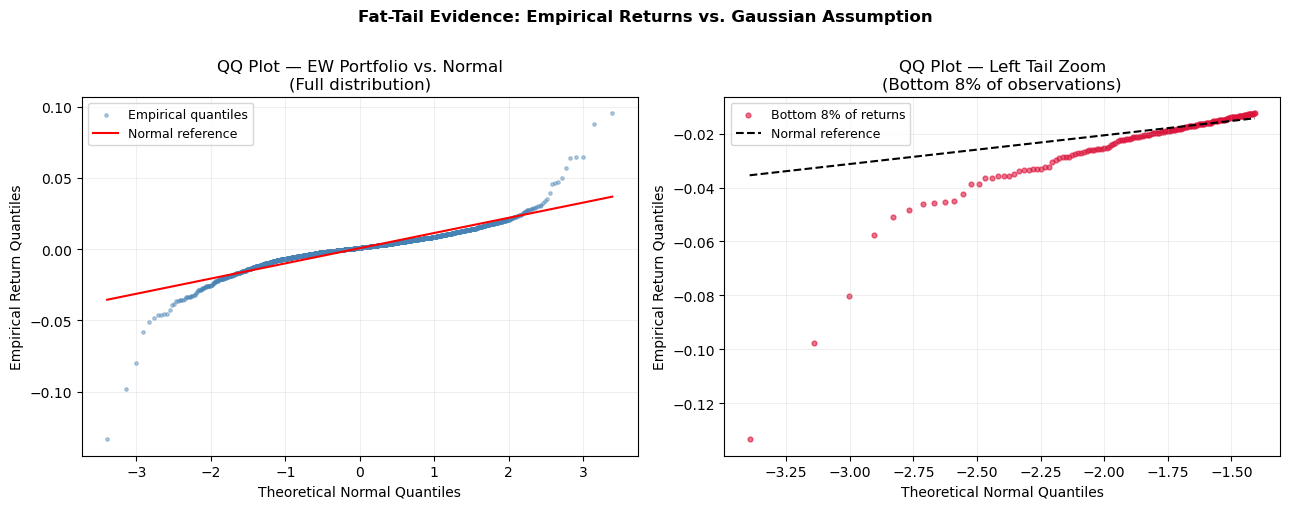

EW portfolio excess kurtosis (train): 19.28  (Gaussian = 0)
A Student-t with nu≈4/10 degrees of freedom would approximate this tail weight.


In [157]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np

ew_train_ret = X_train_returns.mean(axis=1).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: Full QQ plot ---
ax = axes[0]
(osm, osr), (slope, intercept, r) = stats.probplot(ew_train_ret, dist="norm", fit=True)
ax.scatter(osm, osr, s=6, alpha=0.4, color="steelblue", label="Empirical quantiles")
ax.plot(osm, slope * np.array(osm) + intercept, color="red",
        linewidth=1.5, label="Normal reference")
ax.set_title("QQ Plot — EW Portfolio vs. Normal\n(Full distribution)")
ax.set_xlabel("Theoretical Normal Quantiles")
ax.set_ylabel("Empirical Return Quantiles")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

# --- Right: Zoom on left tail ---
ax2 = axes[1]
n = len(osr)
tail_n = int(n * 0.08)   # bottom 8 %
ax2.scatter(osm[:tail_n], osr[:tail_n], s=12, alpha=0.6,
            color="crimson", label="Bottom 8% of returns")
ax2.plot(osm[:tail_n], slope * np.array(osm[:tail_n]) + intercept,
         color="black", linewidth=1.5, linestyle="--", label="Normal reference")
ax2.set_title("QQ Plot — Left Tail Zoom\n(Bottom 8% of observations)")
ax2.set_xlabel("Theoretical Normal Quantiles")
ax2.set_ylabel("Empirical Return Quantiles")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.2)

plt.suptitle("Fat-Tail Evidence: Empirical Returns vs. Gaussian Assumption",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Kurtosis of the EW portfolio return
kurt = ew_train_ret.kurtosis()
print(f"EW portfolio excess kurtosis (train): {kurt:.2f}  (Gaussian = 0)")
print(f"A Student-t with nu≈{max(4, round(6/kurt * 10)):.0f}/10 degrees of freedom"
      f" would approximate this tail weight.")


### 3.9 Regime-Conditioned Return Statistics

The table below quantifies how volatility, average absolute return, and tail quantiles change across regimes. The ~2.5× increase in average standard deviation from `low` to `crisis` — and the ~2.8× increase in the worst 1% quantile — is the numerical core of the argument for **conditional** generation: a single unconditional distribution cannot capture both the calm and crisis regimes simultaneously.


In [158]:
regime_stats = []

for r in ["low", "normal", "crisis"]:
    subset = data.loc[data["regime"] == r, tickers]
    regime_stats.append({
        "regime": r,
        "avg_abs_return": subset.abs().stack().mean(),
        "avg_std_across_assets": subset.std().mean(),
        "worst_1pct_quantile_avg": subset.quantile(0.01).mean(),
        "best_99pct_quantile_avg": subset.quantile(0.99).mean()
    })

regime_stats = pd.DataFrame(regime_stats).set_index("regime")
print(regime_stats.round(4))

        avg_abs_return  avg_std_across_assets  worst_1pct_quantile_avg  \
regime                                                                   
low             0.0084                 0.0118                  -0.0285   
normal          0.0115                 0.0160                  -0.0411   
crisis          0.0208                 0.0291                  -0.0796   

        best_99pct_quantile_avg  
regime                           
low                      0.0317  
normal                   0.0409  
crisis                   0.0746  


### 3.10 Cross-Asset Correlation Structure

Comparing the correlation heatmap on all days vs. crisis-only days reveals **correlation contagion**: during crises, assets that are weakly correlated under normal conditions become highly synchronized. This is exactly what unconditional Gaussian copulas miss — and what the conditional normalizing flow must learn to reproduce when VIX conditioning signals `crisis`.


Is there also negative correlation???

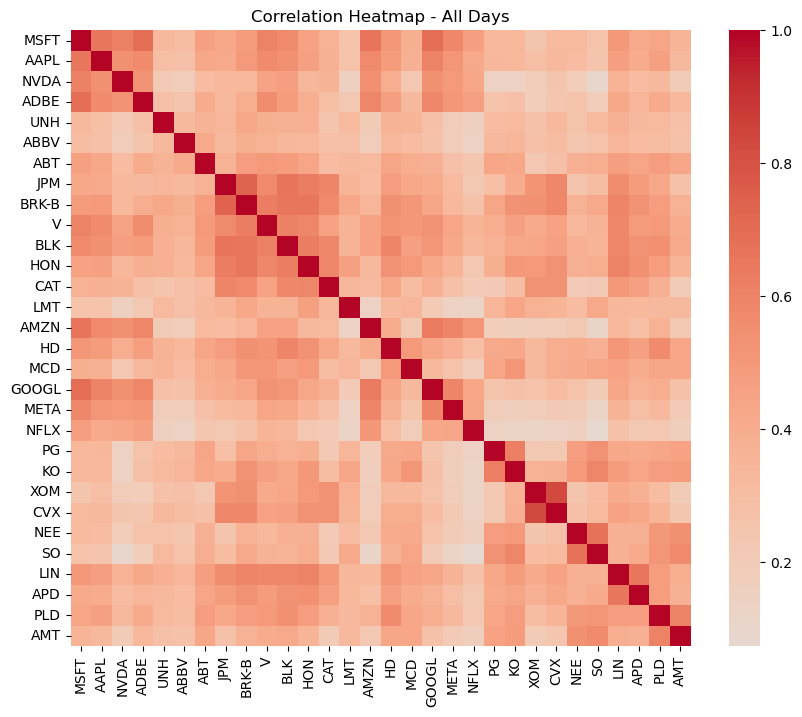

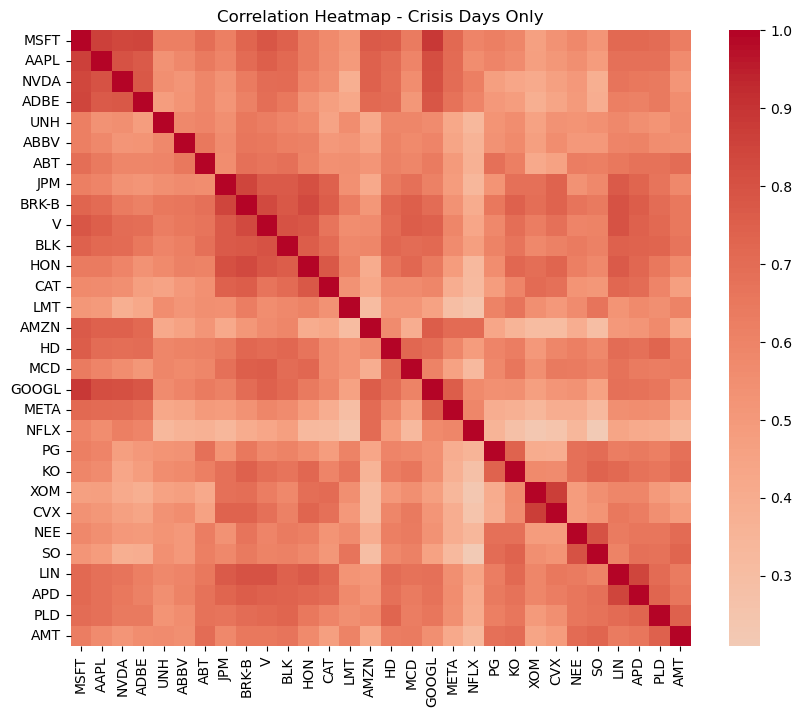

In [159]:
import seaborn as sns

corr_all = data[tickers].corr()
corr_crisis = data.loc[data["regime"] == "crisis", tickers].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_all, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - All Days")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_crisis, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Crisis Days Only")
plt.show()

#### Average Pairwise Correlation by Regime

The heatmaps are compelling visually, but the single number below makes the argument quantitatively. A roughly **2× jump** in average correlation from `low` to `crisis` means that naive diversification breaks down exactly when it is needed most.


In [160]:
import numpy as np

print("Average pairwise cross-asset correlation by VIX regime:")
print("-" * 50)
for r in ["low", "normal", "crisis"]:
    corr_mat = data.loc[data["regime"] == r, tickers].corr().values
    # Upper triangle only (exclude diagonal)
    upper_tri = corr_mat[np.triu_indices_from(corr_mat, k=1)]
    print(f"  {r:8s}  avg correlation = {upper_tri.mean():.3f}  "
          f"  (n={len(data[data['regime']==r])} days)")

print()
low_corr  = data.loc[data["regime"]=="low",    tickers].corr().values
cris_corr = data.loc[data["regime"]=="crisis", tickers].corr().values
low_tri   = low_corr[np.triu_indices_from(low_corr, k=1)]
cris_tri  = cris_corr[np.triu_indices_from(cris_corr, k=1)]
print(f"Correlation increase (crisis / low): {cris_tri.mean() / low_tri.mean():.2f}x")
print()
print("This correlation spike during crises is the central failure mode of")
print("unconditional Gaussian models — and the primary motivation for conditioning")
print("the normalizing flow on the VIX regime.")


Average pairwise cross-asset correlation by VIX regime:
--------------------------------------------------
  low       avg correlation = 0.146    (n=925 days)
  normal    avg correlation = 0.267    (n=1230 days)
  crisis    avg correlation = 0.595    (n=356 days)

Correlation increase (crisis / low): 4.07x

This correlation spike during crises is the central failure mode of
unconditional Gaussian models — and the primary motivation for conditioning
the normalizing flow on the VIX regime.


### 3.11 Worst-Day Tail Analysis

The table below ranks the 15 worst equal-weight portfolio days. All are crisis-regime days. The March 2020 COVID crash dominates, but the April 2025 tariff shock (−5.8%, VIX=45) is the 4th worst day in the dataset — a reminder that extreme events are not a thing of the past and occur well within our training window.


            EW_portfolio_return    VIX  regime
Date                                          
2020-03-16            -0.133444  82.69  crisis
2020-03-12            -0.097752  75.47  crisis
2020-03-09            -0.080172  54.46  crisis
2025-04-04            -0.057881  45.31  crisis
2020-06-11            -0.057802  40.79  crisis
2020-03-18            -0.051089  76.45  crisis
2020-04-01            -0.048232  57.06  crisis
2020-02-27            -0.046274  39.16  crisis
2020-03-20            -0.045930  66.04  crisis
2020-03-11            -0.045474  53.90  crisis
2022-09-13            -0.045157  27.27  crisis
2018-02-05            -0.042503  37.32  crisis
2022-06-13            -0.038826  34.02  crisis
2018-02-08            -0.038729  33.46  crisis
2022-04-29            -0.036593  33.40  crisis


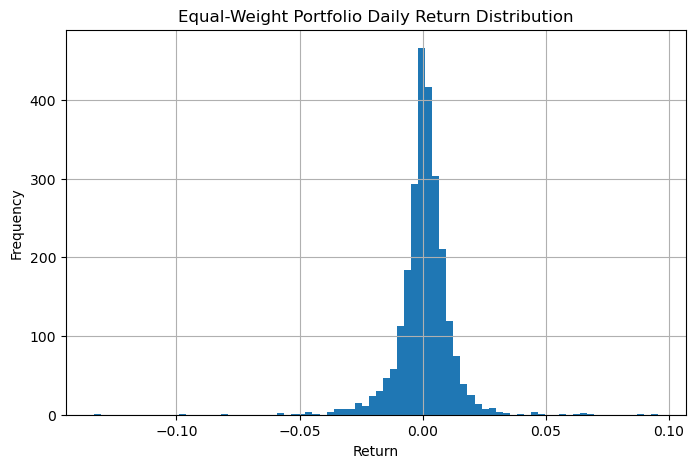

In [161]:
ew_ret = returns.mean(axis=1)
tail_table = pd.DataFrame({
    "EW_portfolio_return": ew_ret,
    "VIX": data["VIX"],
    "regime": data["regime"]
}).sort_values("EW_portfolio_return")

print(tail_table.head(15))

tail_table["EW_portfolio_return"].hist(bins=80, figsize=(8,5))
plt.title("Equal-Weight Portfolio Daily Return Distribution")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()

DO absolute value version of the above graph ^^

### 3.12 Baseline Validation: Gaussian CVaR Under-Estimation

Before building the normalizing flow, we demonstrate the core failure of the Gaussian baseline directly on training data. We:
1. Fit a Gaussian to the training returns (with Ledoit–Wolf shrinkage covariance).
2. Draw 10,000 Monte Carlo samples.
3. Compute the simulated CVaR₀.₉₅ of an equal-weight portfolio.
4. Compare to the **empirical** CVaR₀.₉₅ on the same training data.

A large gap here is the quantitative justification for the conditional flow model.


  Gaussian Baseline vs. Empirical — CVaR Comparison
  Empirical CVaR₀.₉₅  (train): -0.0284
  Gaussian  CVaR₀.₉₅  (train): -0.0232
  Under-estimation gap:         -18.4%

The Gaussian model under-estimates extreme losses by the gap above.
This directly motivates using a fat-tailed, regime-conditioned
normalizing flow to produce more realistic tail scenarios.


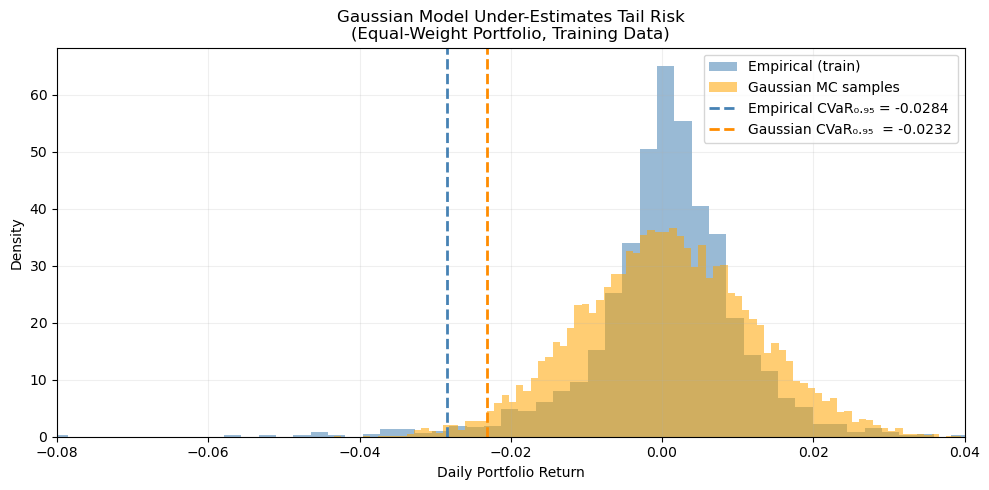

In [162]:
import numpy as np
from sklearn.covariance import LedoitWolf

train_returns_arr = X_train_returns.values   # shape (T, 30)
n_assets = train_returns_arr.shape[1]
weights_ew = np.ones(n_assets) / n_assets

# --- Empirical CVaR on training data ---
ew_train_ret = train_returns_arr @ weights_ew
var_95_empirical = np.percentile(ew_train_ret, 5)
cvar_95_empirical = ew_train_ret[ew_train_ret <= var_95_empirical].mean()

# --- Gaussian fit (Ledoit-Wolf shrinkage covariance) ---
lw = LedoitWolf().fit(train_returns_arr)
mu_hat = train_returns_arr.mean(axis=0)
sigma_hat = lw.covariance_

np.random.seed(42)
S = 10_000
gaussian_samples = np.random.multivariate_normal(mu_hat, sigma_hat, size=S)
ew_gaussian_ret = gaussian_samples @ weights_ew
var_95_gaussian = np.percentile(ew_gaussian_ret, 5)
cvar_95_gaussian = ew_gaussian_ret[ew_gaussian_ret <= var_95_gaussian].mean()

# --- Summary ---
gap_pct = (cvar_95_empirical - cvar_95_gaussian) / abs(cvar_95_empirical) * 100

print("=" * 55)
print("  Gaussian Baseline vs. Empirical — CVaR Comparison")
print("=" * 55)
print(f"  Empirical CVaR₀.₉₅  (train): {cvar_95_empirical:.4f}")
print(f"  Gaussian  CVaR₀.₉₅  (train): {cvar_95_gaussian:.4f}")
print(f"  Under-estimation gap:         {gap_pct:.1f}%")
print("=" * 55)
print()
print("The Gaussian model under-estimates extreme losses by the gap above.")
print("This directly motivates using a fat-tailed, regime-conditioned")
print("normalizing flow to produce more realistic tail scenarios.")

# --- Visualization ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ew_train_ret,    bins=100, alpha=0.55, color="steelblue",
        density=True, label="Empirical (train)")
ax.hist(ew_gaussian_ret, bins=100, alpha=0.55, color="orange",
        density=True, label="Gaussian MC samples")
ax.axvline(cvar_95_empirical, color="steelblue", linewidth=2,
           linestyle="--", label=f"Empirical CVaR₀.₉₅ = {cvar_95_empirical:.4f}")
ax.axvline(cvar_95_gaussian, color="darkorange", linewidth=2,
           linestyle="--", label=f"Gaussian CVaR₀.₉₅  = {cvar_95_gaussian:.4f}")
ax.set_xlim(-0.08, 0.04)
ax.set_title("Gaussian Model Under-Estimates Tail Risk\n(Equal-Weight Portfolio, Training Data)")
ax.set_xlabel("Daily Portfolio Return")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## Section 4: Stress-Focused Evaluation Setup

The chronological 80/20 split is the primary holdout design, but the test window (March 2024 – March 2026) is relatively calm compared to the full training period. To ensure we can evaluate model performance where it matters most, we construct several **stress-focused subsets** of the test set.

> **Important — Regime Imbalance in the Test Set:** The test window has only **28 crisis days (5.6%)** vs. 16.3% crisis days in training. This is an artifact of the temporal split falling in a period of lower volatility. Evaluation on the full test set will therefore be dominated by calm-market days. We address this by reporting metrics on the `crisis_only` and `tail_5pct` subsets separately. The normalizing flow's regime conditioning should still be evaluated in crisis mode even if the held-out test period happens to be calm.


## Stress-Focused Evaluation Additions

The chronological 80/20 split is still the main holdout design, but the final test window can be relatively calm. These cells add diagnostics and stress-focused subsets so model performance can be evaluated on the full test set **and** on crisis/tail periods where downside-risk modeling matters most.


In [163]:
# -----------------------------
# Test-set stress diagnostics
# -----------------------------
print("Test regime counts:")
print(test_data["regime"].value_counts())
print("\nTest regime percentages:")
print((test_data["regime"].value_counts(normalize=True) * 100).round(2))

# Equal-weight portfolio return on the test set
test_ew_ret = test_data[tickers].mean(axis=1)

print("\nTest equal-weight return summary:")
print(test_ew_ret.describe(percentiles=[0.01, 0.05, 0.10, 0.90, 0.95, 0.99]).round(4))


Test regime counts:
regime
normal    352
low       123
crisis     28
Name: count, dtype: int64

Test regime percentages:
regime
normal    69.98
low       24.45
crisis     5.57
Name: proportion, dtype: float64

Test equal-weight return summary:
count    503.0000
mean       0.0004
std        0.0077
min       -0.0579
1%        -0.0216
5%        -0.0103
10%       -0.0079
50%        0.0008
90%        0.0084
95%        0.0102
99%        0.0154
max        0.0695
dtype: float64


In [164]:
# -----------------------------
# Stress-focused test subsets
# -----------------------------

# Work on a copy so we do not accidentally overwrite earlier objects
test_eval = test_data.copy()

# Equal-weight portfolio return on the full test set
test_eval["EW_portfolio_return"] = test_eval[tickers].mean(axis=1)

# Crisis-only subset based on your regime labels
test_crisis = test_eval[test_eval["regime"] == "crisis"].copy()

# High-VIX subset using the same crisis threshold logic
test_high_vix = test_eval[test_eval["VIX"] >= 25].copy()

# Worst 5% days in the test set
tail_5_threshold = test_eval["EW_portfolio_return"].quantile(0.05)
test_tail_5 = test_eval[test_eval["EW_portfolio_return"] <= tail_5_threshold].copy()

# Worst 1% days in the test set
tail_1_threshold = test_eval["EW_portfolio_return"].quantile(0.01)
test_tail_1 = test_eval[test_eval["EW_portfolio_return"] <= tail_1_threshold].copy()

print("Full test days:", len(test_eval))
print("Crisis test days:", len(test_crisis))
print("High-VIX test days:", len(test_high_vix))
print("Worst 5% test days:", len(test_tail_5))
print("Worst 1% test days:", len(test_tail_1))


Full test days: 503
Crisis test days: 28
High-VIX test days: 28
Worst 5% test days: 26
Worst 1% test days: 6


In [165]:
# -----------------------------
# Compare the stress level of each test subset
# -----------------------------
subset_summary = pd.DataFrame([
    {
        "subset": "full_test",
        "n_days": len(test_eval),
        "avg_abs_return": test_eval[tickers].abs().stack().mean(),
        "avg_std_across_assets": test_eval[tickers].std().mean(),
        "avg_VIX": test_eval["VIX"].mean(),
        "avg_EW_return": test_eval["EW_portfolio_return"].mean(),
        "worst_day": test_eval["EW_portfolio_return"].min()
    },
    {
        "subset": "crisis_only",
        "n_days": len(test_crisis),
        "avg_abs_return": test_crisis[tickers].abs().stack().mean(),
        "avg_std_across_assets": test_crisis[tickers].std().mean(),
        "avg_VIX": test_crisis["VIX"].mean(),
        "avg_EW_return": test_crisis["EW_portfolio_return"].mean(),
        "worst_day": test_crisis["EW_portfolio_return"].min()
    },
    {
        "subset": "high_vix",
        "n_days": len(test_high_vix),
        "avg_abs_return": test_high_vix[tickers].abs().stack().mean(),
        "avg_std_across_assets": test_high_vix[tickers].std().mean(),
        "avg_VIX": test_high_vix["VIX"].mean(),
        "avg_EW_return": test_high_vix["EW_portfolio_return"].mean(),
        "worst_day": test_high_vix["EW_portfolio_return"].min()
    },
    {
        "subset": "tail_5pct",
        "n_days": len(test_tail_5),
        "avg_abs_return": test_tail_5[tickers].abs().stack().mean(),
        "avg_std_across_assets": test_tail_5[tickers].std().mean(),
        "avg_VIX": test_tail_5["VIX"].mean(),
        "avg_EW_return": test_tail_5["EW_portfolio_return"].mean(),
        "worst_day": test_tail_5["EW_portfolio_return"].min()
    }
])

print(subset_summary.round(4))


        subset  n_days  avg_abs_return  avg_std_across_assets  avg_VIX  \
0    full_test     503          0.0115                 0.0164  17.8038   
1  crisis_only      28          0.0212                 0.0291  31.8582   
2     high_vix      28          0.0212                 0.0291  31.8582   
3    tail_5pct      26          0.0214                 0.0210  25.6512   

   avg_EW_return  worst_day  
0         0.0004    -0.0579  
1        -0.0053    -0.0579  
2        -0.0053    -0.0579  
3        -0.0173    -0.0579  


In [166]:
# -----------------------------
# Evaluation helpers for later model comparison
# -----------------------------
def summarize_portfolio_returns(port_ret, label="subset"):
    port_ret = pd.Series(port_ret).dropna()

    var_95 = port_ret.quantile(0.05)
    cvar_95 = port_ret[port_ret <= var_95].mean()

    return pd.Series({
        "subset": label,
        "n_days": len(port_ret),
        "mean": port_ret.mean(),
        "std": port_ret.std(),
        "min": port_ret.min(),
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })

def evaluate_by_subset(port_ret_series, subset_dict):
    port_ret_series = pd.Series(port_ret_series).dropna()
    results = []

    for subset_name, subset_df in subset_dict.items():
        aligned = port_ret_series.loc[subset_df.index].dropna()
        results.append(summarize_portfolio_returns(aligned, label=subset_name))

    return pd.DataFrame(results)

subset_dict = {
    "full_test": test_eval,
    "crisis_only": test_crisis,
    "high_vix": test_high_vix,
    "tail_5pct": test_tail_5,
    "tail_1pct": test_tail_1
}


### 4.5 Model Comparison Template

The cell below is a **placeholder** — it will be run in the modeling notebooks once `gaussian_test_portfolio_returns` and `flow_test_portfolio_returns` are available as date-indexed Series objects. It shows how to call `evaluate_by_subset` consistently across all model variants.


In [167]:
# -----------------------------
# Example model comparison across stress-focused test subsets
# Run this cell after you create date-indexed portfolio-return series for each model
# -----------------------------
required_vars = ["gaussian_test_portfolio_returns", "flow_test_portfolio_returns"]
missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    print("Run this cell after creating the following date-indexed Series:")
    print(", ".join(missing_vars))
else:
    gaussian_results = evaluate_by_subset(gaussian_test_portfolio_returns, subset_dict)
    gaussian_results["approach"] = "Gaussian"

    flow_results = evaluate_by_subset(flow_test_portfolio_returns, subset_dict)
    flow_results["approach"] = "Flow"

    comparison = pd.concat([gaussian_results, flow_results], axis=0, ignore_index=True)
    comparison = comparison[["approach", "subset", "n_days", "mean", "std", "min", "VaR_95", "CVaR_95"]]

    print(comparison.round(4))


Run this cell after creating the following date-indexed Series:
gaussian_test_portfolio_returns, flow_test_portfolio_returns


## Section 5: Gaussian MC Baseline (Risk-Neutral Optimization)

We now implement the risk-neutral baseline described in the proposal. The objective is to minimize expected portfolio loss J(x,θ) = −x⊤θ over S=10,000 Gaussian samples drawn from the Ledoit-Wolf fitted distribution, subject to the simplex constraint (weights sum to 1, no shorting).

One important note: since this objective is linear in x, it reduces analytically to maximizing expected return — which tends to concentrate weight in high-mean assets. This is intentional. It shows the failure mode of a purely risk-neutral objective: it ignores variance and tail risk entirely, which is exactly what CVaR optimization corrects for.

In [168]:
import numpy as np
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize

# --- Fit Gaussian to training data ---
train_arr = X_train_returns.values        # shape (T, 30)
n_assets   = train_arr.shape[1]

lw = LedoitWolf().fit(train_arr)
mu_hat    = train_arr.mean(axis=0)        # (30,)
sigma_hat = lw.covariance_               # (30, 30)

# --- Draw S Gaussian scenarios ---
S = 10_000
np.random.seed(42)
gaussian_scenarios = np.random.multivariate_normal(mu_hat, sigma_hat, size=S)
# shape: (10000, 30)

# --- SLSQP: minimize expected loss = minimize -x^T * mean(scenarios) ---
def expected_loss(w):
    # (1/S) * sum_s [ -w^T θ^(s) ] = -w^T μ̂_sample
    return -w @ gaussian_scenarios.mean(axis=0)

def expected_loss_grad(w):
    return -gaussian_scenarios.mean(axis=0)

constraints = {"type": "eq", "fun": lambda w: w.sum() - 1}
bounds      = [(0, 1)] * n_assets
w0          = np.ones(n_assets) / n_assets   # equal-weight init

result = minimize(
    expected_loss,
    w0,
    jac=expected_loss_grad,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"ftol": 1e-12, "maxiter": 1000}
)

gaussian_weights = result.x

print(f"Optimization converged: {result.success}  |  message: {result.message}")
print(f"\nTop 10 holdings (Gaussian risk-neutral):")
weight_series = pd.Series(gaussian_weights, index=tickers).sort_values(ascending=False)
print(weight_series.head(10).round(4))
print(f"\nEffective N (1/sum(w²)): {1/np.sum(gaussian_weights**2):.1f} stocks")

Optimization converged: True  |  message: Optimization terminated successfully

Top 10 holdings (Gaussian risk-neutral):
NVDA    1.0
LMT     0.0
META    0.0
JPM     0.0
NFLX    0.0
APD     0.0
CAT     0.0
KO      0.0
PLD     0.0
HD      0.0
dtype: float64

Effective N (1/sum(w²)): 1.0 stocks


In [169]:
# --- Apply weights to test set → gaussian_test_portfolio_returns ---
gaussian_test_portfolio_returns = (
    X_test_returns @ gaussian_weights
)
# This is now a date-indexed Series — ready for the model comparison template

# --- Quick performance summary ---
ret = gaussian_test_portfolio_returns
var_95  = np.percentile(ret, 5)
cvar_95 = ret[ret <= var_95].mean()
sharpe  = ret.mean() / ret.std() * np.sqrt(252)

print("Gaussian Risk-Neutral Portfolio — Test Set Performance")
print("=" * 50)
print(f"  Annualized Sharpe:  {sharpe:.3f}")
print(f"  Daily mean return:  {ret.mean():.4f}")
print(f"  Daily std:          {ret.std():.4f}")
print(f"  VaR₀.₉₅:            {var_95:.4f}")
print(f"  CVaR₀.₉₅:           {cvar_95:.4f}")
print(f"  Max drawdown day:   {ret.min():.4f}")
print()

# --- Also compute on crisis-only test subset ---
crisis_ret = gaussian_test_portfolio_returns.loc[test_crisis.index]
crisis_var  = np.percentile(crisis_ret, 5)
crisis_cvar = crisis_ret[crisis_ret <= crisis_var].mean()

print("Gaussian Risk-Neutral Portfolio — Crisis Test Subset")
print("=" * 50)
print(f"  Daily mean return:  {crisis_ret.mean():.4f}")
print(f"  CVaR₀.₉₅:           {crisis_cvar:.4f}")
print(f"  Worst day:          {crisis_ret.min():.4f}")

Gaussian Risk-Neutral Portfolio — Test Set Performance
  Annualized Sharpe:  0.702
  Daily mean return:  0.0014
  Daily std:          0.0310
  VaR₀.₉₅:            -0.0478
  CVaR₀.₉₅:           -0.0727
  Max drawdown day:   -0.1859

Gaussian Risk-Neutral Portfolio — Crisis Test Subset
  Daily mean return:  -0.0086
  CVaR₀.₉₅:           -0.0789
  Worst day:          -0.0813


In [170]:
# Use full test VaR threshold, applied to crisis returns
crisis_cvar_fixed = crisis_ret[crisis_ret <= var_95].mean()
print(f"CVaR₀.₉₅ (crisis, using full-test threshold): {crisis_cvar_fixed:.4f}")

CVaR₀.₉₅ (crisis, using full-test threshold): -0.0657
